In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset, Dataset
import numpy as np
import pyreadr

c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load = pyreadr.read_r("c:\\Users\\Maxim\\dsi-capstone-fall-2024-team-forecasting-treasury-yield\\Data\\cleaned_monthly_data.RData")

In [3]:
features_cols = ['tenyr_yield', "GDP_based_recession_indicator", "umich_inflation_excpectation", "industrial_production_consumer_goods",
                  "equity_market_volatility", "yen_dollar_exchange_rate", "producer_price_index_construction_materials",
                  "10yr_expected_inflation", "30yr_yield", "velocity_of_m1_money_stock", "yield_stdev", "federal_funds_effective_rate"]

In [4]:
monthly_1985 = load['monthly_1985']
#monthly_1985['yield_5yr_ahead'] = monthly_1985['tenyr_yield'].shift(-60)
monthly_1985 = monthly_1985.dropna()

#y = monthly_1985[['yield_5yr_ahead']]
#features = monthly_1985.drop(columns=['month'])

features = monthly_1985[features_cols]

In [5]:
class TimeSeriesDataSet(Dataset):
    def __init__(self, data, inner_window_size, forecast_horizon=60):
        self.sequences = []
        self.targets = []

        for i in range(len(data) - inner_window_size - forecast_horizon + 1):
            self.sequences.append(data[i:i + inner_window_size])
            self.targets.append(data[i + inner_window_size + forecast_horizon - 1, 0])

        
        self.sequences = torch.Tensor(self.sequences)
        self.targets = torch.Tensor(self.targets)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]


In [149]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.35):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x, hidden=None):
        if hidden is None:
            hidden = self.init_hidden(x.size(0), x.device)
        
        out, hidden = self.gru(x, hidden)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out, hidden
    
    def init_hidden(self, batch_size, device):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)

In [132]:
class NestedWindowGRU:
    def __init__(self, outer_window_size, inner_window_size, n_features, forecast_horizon=60, 
                 hidden_size=64, num_layers=2, batch_size=32):
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = GRUModel(n_features, hidden_size, num_layers).to(self.device)
        self.outer_window_size = outer_window_size
        self.inner_window_size = inner_window_size
        self.forecast_horizon = forecast_horizon
        self.n_features = n_features
        self.batch_size = batch_size
        self.scalers = [MinMaxScaler() for _ in range(n_features)]
        self.criterion = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001, weight_decay=1e-5)
    
    def scale_data(self, data, fit=True):
        scaled_data = np.zeros_like(data)
        for i in range(self.n_features):
            if fit:
                scaled_data[:, i] = self.scalers[i].fit_transform(data[:, i].reshape(-1, 1)).ravel()
            else:
                scaled_data[:, i] = self.scalers[i].transform(data[:, i].reshape(-1, 1)).ravel()
        return scaled_data
    
    def inverse_scale(self, data, feature_idx=0):
        return self.scalers[feature_idx].inverse_transform(data.reshape(-1, 1))

    def train_window(self, train_data, epochs=1):

        self.model.train()

        scaled_data = self.scale_data(train_data)

        dataset = TimeSeriesDataSet(scaled_data, self.inner_window_size, self.forecast_horizon)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        for epoch in range(epochs):
            total_loss = 0.0
            hidden = self.model.init_hidden(self.batch_size, self.device)


            for sequences, targets in dataloader:
                sequences = sequences.to(self.device)
                targets = targets.to(self.device)


                if sequences.size(0) != hidden.size(1):
                    hidden = self.model.init_hidden(sequences.size(0), self.device)
                

                self.optimizer.zero_grad()
                outputs, hidden = self.model(sequences, hidden)
                loss = self.criterion(outputs.squeeze(), targets)
                loss.backward()
                hidden = hidden.detach()


                self.optimizer.step()
                total_loss += loss.item()

            avg_loss = total_loss / len(dataloader)
            print(f"Epoch [{epoch+1} / {epochs}], loss: {avg_loss:.4f}")

    
    def predict_next(self, sequence):

        self.model.eval()
        with torch.no_grad():

            scaled_seq = self.scale_data(sequence[-self.inner_window_size:], fit=False)

            seq_tensor = torch.Tensor(scaled_seq).unsqueeze(0).to(self.device)

            prediction, _ = self.model(seq_tensor)

            return self.inverse_scale(prediction.cpu().numpy())[0][0]

In [133]:
def nested_walk_forward_validation(data, outer_window_size, inner_window_size, forecast_horizon = 60, step_size=1):

    n_features = data.shape[1]
    predictions = []
    actual_values = []

    for i in range(0, len(data) - outer_window_size - forecast_horizon, step_size):
        gru = NestedWindowGRU(outer_window_size, inner_window_size, n_features, forecast_horizon)

        train_window = data[i:i + outer_window_size]

        test_point = data[i + outer_window_size + forecast_horizon - 1, 0]

        gru.train_window(train_window)

        prediction = gru.predict_next(train_window)

        predictions.append(prediction)
        actual_values.append(test_point)

        print(f"Outer Window {i//step_size + 1}")
        print(f"Prediction: {prediction:.4f}, Actual: {test_point:.4f}")

    return np.array(predictions), np.array(actual_values)

In [154]:
outer_window_size = 120
inner_window_size = 60
step_size = 1

predictions, actuals = nested_walk_forward_validation(features.to_numpy(), outer_window_size,
                                                      inner_window_size, forecast_horizon=60,
                                                      step_size=step_size)



c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due t

Epoch [1 / 1], loss: 0.3230
Outer Window 1
Prediction: 4.7578, Actual: 6.2706
Epoch [1 / 1], loss: 0.1005
Outer Window 2
Prediction: 6.1068, Actual: 6.6494
Epoch [1 / 1], loss: 0.2782
Outer Window 3
Prediction: 4.6081, Actual: 6.5138
Epoch [1 / 1], loss: 0.0612
Outer Window 4
Prediction: 6.0733, Actual: 6.2665
Epoch [1 / 1], loss: 0.2416
Outer Window 5
Prediction: 5.0979, Actual: 5.9910
Epoch [1 / 1], loss: 0.0369
Outer Window 6
Prediction: 5.9762, Actual: 6.4432
Epoch [1 / 1], loss: 0.0158
Outer Window 7
Prediction: 5.7549, Actual: 6.1020
Epoch [1 / 1], loss: 0.0049
Outer Window 8
Prediction: 5.9083, Actual: 6.0471
Epoch [1 / 1], loss: 0.0188
Outer Window 9
Prediction: 6.1596, Actual: 5.8200
Epoch [1 / 1], loss: 0.2383
Outer Window 10
Prediction: 4.8822, Actual: 5.7887
Epoch [1 / 1], loss: 0.0002
Outer Window 11
Prediction: 5.8831, Actual: 5.7403


c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due t

Epoch [1 / 1], loss: 0.0109
Outer Window 12
Prediction: 5.3751, Actual: 5.7220
Epoch [1 / 1], loss: 0.0719
Outer Window 13
Prediction: 4.6807, Actual: 5.2339
Epoch [1 / 1], loss: 0.0065
Outer Window 14
Prediction: 5.2496, Actual: 5.1635
Epoch [1 / 1], loss: 0.0001
Outer Window 15
Prediction: 5.2999, Actual: 5.1004
Epoch [1 / 1], loss: 0.1518
Outer Window 16
Prediction: 4.8556, Actual: 4.8829
Epoch [1 / 1], loss: 0.0887
Outer Window 17
Prediction: 5.2019, Actual: 5.1433
Epoch [1 / 1], loss: 0.1537
Outer Window 18
Prediction: 5.2406, Actual: 5.4010
Epoch [1 / 1], loss: 0.1113
Outer Window 19
Prediction: 5.9713, Actual: 5.2917
Epoch [1 / 1], loss: 0.2506
Outer Window 20
Prediction: 5.1175, Actual: 5.2487
Epoch [1 / 1], loss: 0.1476
Outer Window 21
Prediction: 6.1502, Actual: 4.9761
Epoch [1 / 1], loss: 0.1354
Outer Window 22
Prediction: 5.7302, Actual: 4.7337
Epoch [1 / 1], loss: 0.0153
Outer Window 23
Prediction: 6.3048, Actual: 4.5713
Epoch [1 / 1], loss: 0.0336
Outer Window 24
Predicti

c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due t

...

c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due t

Epoch [1 / 1], loss: 0.0215
Outer Window 246
Prediction: 1.8162, Actual: 0.6677
Epoch [1 / 1], loss: 0.0018
Outer Window 247
Prediction: 2.2256, Actual: 0.7317
Epoch [1 / 1], loss: 0.0604
Outer Window 248
Prediction: 1.7371, Actual: 0.6297
Epoch [1 / 1], loss: 0.0781
Outer Window 249
Prediction: 1.5179, Actual: 0.6474
Epoch [1 / 1], loss: 0.0143
Outer Window 250
Prediction: 1.6350, Actual: 0.6830
Epoch [1 / 1], loss: 0.0269
Outer Window 251
Prediction: 1.7377, Actual: 0.7871
Epoch [1 / 1], loss: 0.0709
Outer Window 252
Prediction: 1.3749, Actual: 0.8683
Epoch [1 / 1], loss: 0.0906
Outer Window 253
Prediction: 1.4339, Actual: 0.9355
Epoch [1 / 1], loss: 0.0295
Outer Window 254
Prediction: 1.5137, Actual: 1.0755
Epoch [1 / 1], loss: 0.0321
Outer Window 255
Prediction: 1.5573, Actual: 1.2657
Epoch [1 / 1], loss: 0.0029
Outer Window 256
Prediction: 2.0488, Actual: 1.6216
Epoch [1 / 1], loss: 0.0102
Outer Window 257
Prediction: 1.7226, Actual: 1.6363
Epoch [1 / 1], loss: 0.0295
Outer Window

c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due t

Epoch [1 / 1], loss: 0.5268
Outer Window 292
Prediction: 1.4418, Actual: 4.2061
Epoch [1 / 1], loss: 0.1385
Outer Window 293
Prediction: 1.9404, Actual: 4.5407
Epoch [1 / 1], loss: 0.1294
Outer Window 294
Prediction: 1.6266, Actual: 4.4784
Epoch [1 / 1], loss: 0.0036
Outer Window 295
Prediction: 1.7725, Actual: 4.3173
Epoch [1 / 1], loss: 0.1071
Outer Window 296
Prediction: 1.4354, Actual: 4.2468
Epoch [1 / 1], loss: 0.0836
Outer Window 297
Prediction: 1.8898, Actual: 3.8694
Epoch [1 / 1], loss: 0.0198
Outer Window 298
Prediction: 1.5090, Actual: 3.7337


c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due t

In [155]:
rmse = np.sqrt(np.mean((predictions - actuals)**2))
print(f"\nRoot Mean Squared Error: {rmse:.4f}")


Root Mean Squared Error: 1.0931


In [18]:
len(predictions)

298

In [25]:
import pandas as pd

In [26]:
months = pd.to_datetime(months)

In [27]:
months

0     1985-01-01
1     1985-02-01
2     1985-03-01
3     1985-04-01
4     1985-05-01
         ...    
473   2024-06-01
474   2024-07-01
475   2024-08-01
476   2024-09-01
477   2024-10-01
Name: month, Length: 478, dtype: datetime64[ns]

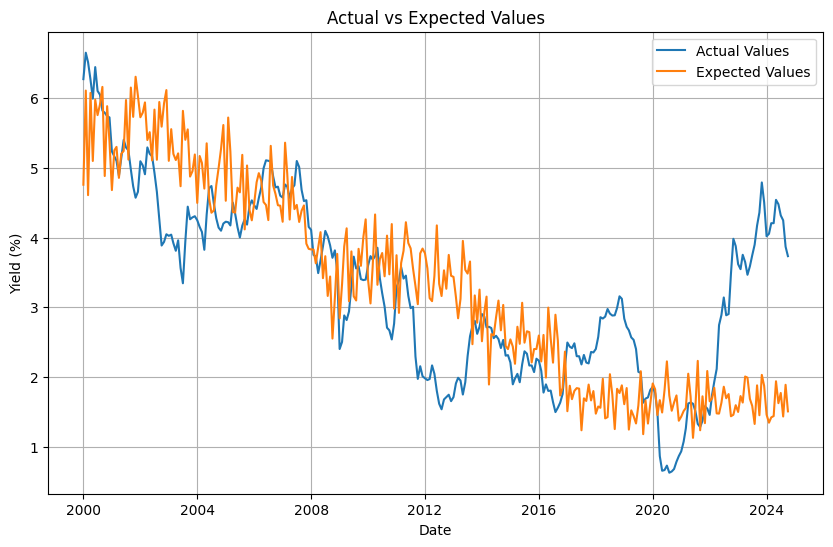

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) 
plt.plot(months[-298:], actuals, label='Actual Values') 
plt.plot(months[-298:], predictions, label='Expected Values') 
plt.xlabel('Date') 
plt.ylabel('Yield (%)') 
plt.title('Actual vs Expected Values') 
plt.legend() 
plt.grid(True)
plt.show()

In [157]:
def calculate_r_squared(actuals, predictions):
    actuals = np.array(actuals)
    predictions = np.array(predictions)
    
    # Mean of actual values
    mean_actual = np.mean(actuals)
    
    # Residual sum of squares (RSS)
    rss = np.sum((actuals - predictions) ** 2)
    
    # Total sum of squares (TSS)
    tss = np.sum((actuals - mean_actual) ** 2)
    
    # R-squared
    r_squared = 1 - (rss / tss)
    return r_squared

In [158]:
calculate_r_squared(actuals, predictions)

0.30578075929598136

In [159]:
def calculate_mape(actuals, predictions):
    actuals = np.array(actuals)
    predictions = np.array(predictions)
    
    # Avoid division by zero by replacing 0 values with a small epsilon
    epsilon = 1e-10
    actuals = np.where(actuals == 0, epsilon, actuals)
    
    # Calculate MAPE
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
    return mape

In [160]:
calculate_mape(actuals, predictions)

31.648273569079915

In [161]:
best_predictions = predictions

best_actuals = actuals

In [92]:
rmse = np.sqrt(np.mean((best_predictions - best_actuals)**2))
print(f"\nRoot Mean Squared Error: {rmse:.4f}")


Root Mean Squared Error: 1.0567


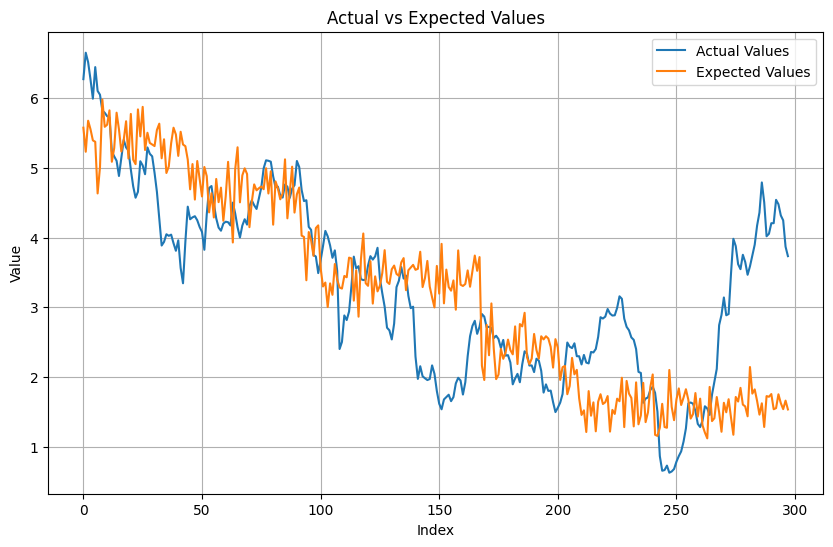

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) 
plt.plot(best_actuals, label='Actual Values') 
plt.plot(best_predictions, label='Expected Values') 
plt.xlabel('Index') 
plt.ylabel('Value') 
plt.title('Actual vs Expected Values') 
plt.legend() 
plt.grid(True)
plt.show()

In [19]:
# Example GRU Model for Forecasting
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # GRU layer
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully connected layer for output
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # GRU layer
        out, _ = self.gru(x, h0)
        
        # Only take the output from the last time step
        out = out[:, -1, :]
        
        # Pass through fully connected layer
        out = self.fc(out)
        return out

In [7]:
device = "cuda"

In [139]:
preds = []
actuals = []


for i in range(0, len(y)-180):

    scaler = StandardScaler()

    feat_train = features[0:120+i]
    y_tr = y[0:120+i]

    feat_test = features[180+i:181+i]
    y_te = y[180+i:181+i]

    feat_train = scaler.fit_transform(feat_train)
    feat_test = scaler.transform(feat_test)

    # Convert data to PyTorch tensors
    X_train = torch.Tensor(feat_train).unsqueeze(1)
    y_train = torch.Tensor(y_tr.to_numpy())

    X_test = torch.Tensor(feat_test).unsqueeze(1)
    y_test = torch.Tensor(y_te.to_numpy())

    # Define the model, loss function, and optimizer
    input_size = feat_train.shape[1]  # 1 feature (10-year treasury yield)
    hidden_size = 32
    output_size = 1  # Predict 1 value (yield in 5 years)
    model = GRUModel(input_size, hidden_size, output_size)
    model.to(device)

    # Hyperparameters
    learning_rate = 0.001
    num_epochs = 100
    batch_size = 16

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_dataset = TensorDataset(X_train, y_train) 
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False) 
    # Main training loop 
    for epoch in range(num_epochs): 
        model.train() 
        tr_loss = 0 
        for batch in train_loader: 
            # Move batch to device 
            batch = [item.to(device) for item in batch] 
            inputs, targets = batch 
            # Zero the gradients 
            optimizer.zero_grad() 
            # Forward pass 
            outputs = model(inputs) 
            # Compute the loss 
            loss = criterion(outputs, targets) 
            tr_loss += loss.item() 
            # Backward pass and optimization 
            loss.backward() 
            optimizer.step() 
            #if (epoch + 1) % 10 == 0: 
            #    avg_loss = tr_loss / len(train_loader) 
            #    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}') 
            # After training, use the model for forecasting 

    model.eval() 
    with torch.no_grad(): 
        X_test = X_test.to(device) 
        predictions = model(X_test) 
        print("Predictions:", predictions)
        print("True Value:", y_test)
        preds.append(predictions.cpu().numpy()[0][0])
        actuals.append(y_test.numpy()[0][0])


Predictions: tensor([[4.4636]], device='cuda:0')
True Value: tensor([[4.2200]])
Predictions: tensor([[4.4764]], device='cuda:0')
True Value: tensor([[4.1739]])
Predictions: tensor([[3.9262]], device='cuda:0')
True Value: tensor([[4.5010]])
Predictions: tensor([[4.3331]], device='cuda:0')
True Value: tensor([[4.3450]])
Predictions: tensor([[4.1271]], device='cuda:0')
True Value: tensor([[4.1465]])
Predictions: tensor([[4.2612]], device='cuda:0')
True Value: tensor([[4.0013]])
Predictions: tensor([[4.9438]], device='cuda:0')
True Value: tensor([[4.1719]])
Predictions: tensor([[4.4253]], device='cuda:0')
True Value: tensor([[4.2626]])
Predictions: tensor([[4.7483]], device='cuda:0')
True Value: tensor([[4.1857]])
Predictions: tensor([[6.1339]], device='cuda:0')
True Value: tensor([[4.4484]])
Predictions: tensor([[5.9880]], device='cuda:0')
True Value: tensor([[4.5333]])
Predictions: tensor([[5.8295]], device='cuda:0')
True Value: tensor([[4.4632]])
Predictions: tensor([[4.7157]], device='

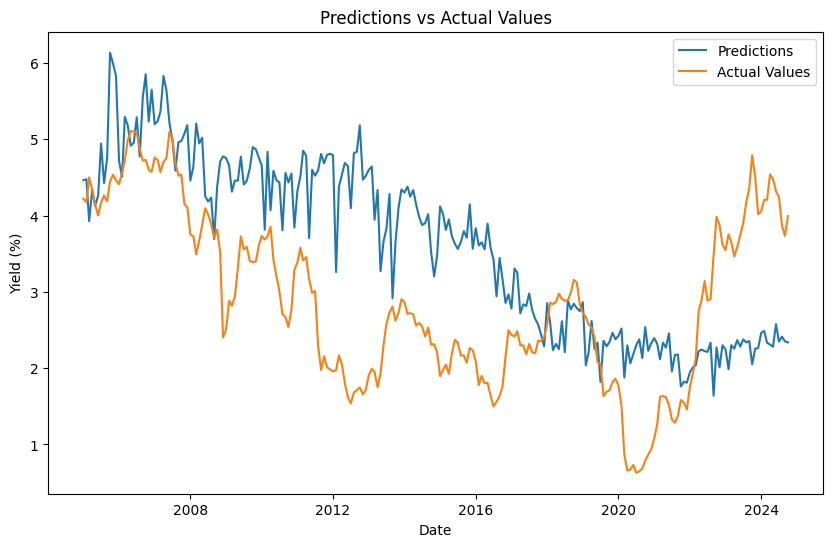

In [140]:
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score 
import pandas as pd
# Plotting 

dates = monthly_1985["month"][180:418] + pd.DateOffset(years=5)

plt.figure(figsize=(10, 6)) 
plt.plot(dates, preds, label='Predictions') 
plt.plot(dates, actuals, label='Actual Values') 
plt.legend() 
plt.title("Predictions vs Actual Values") 
plt.xlabel("Date") 
plt.ylabel("Yield (%)") 
plt.show() 

In [1]:
# Calculating Metrics 
rmse = np.sqrt(mean_squared_error(actuals, preds)) 
mape = mean_absolute_percentage_error(actuals, preds) 
r2 = r2_score(actuals, preds) 
print(f"RMSE: {rmse:.4f}") 
print(f"MAPE: {mape:.4f}") 
print(f"R^2: {r2:.4f}")

NameError: name 'np' is not defined